In [14]:
import aopy
from aopy.data import db
from aopy.analysis import accllr
import os
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import h5py
import traceback
from scipy.stats import zscore
import datetime
from tqdm.auto import tqdm
from IPython.display import display, Markdown
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

from aopy.visualization import annotate_spatial_map_channels, place_Opto32_subplots
from aopy.data.bmi3d import tabulate_ts_data
from aopy.preproc.bmi3d import get_laser_trial_times
from aopy.preproc.quality import detect_bad_trials
from aopy.analysis.connectivity import get_acq_ch_near_stimulation_site
from aopy.analysis.connectivity import calc_connectivity_map_coh
from aopy.visualization import plot_angles, overlay_sulci_on_spatial_map
from aopy.analysis import calc_itpc, calc_fdrc_ranktest, calc_spatial_data_correlation
from aopy.analysis.latency import detect_itpc_response
from aopy.visualization import plot_annotated_stim_drive_data

data_dir = '/media/moor-data/raw'
preproc_dir = '/media/moor-data/preprocessed'
postproc_dir = '/data/postprocessed/leo'
fig_dir = './figures'

version = 'v260218'


In [3]:
sns.set_theme('paper', style='ticks', font_scale=1, font="Arial", rc={
    'svg.fonttype': 'none',
    "font.size" : 10,
    "axes.labelsize" : 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

In [4]:
from connectivity_analysis import *
from connectivity_plotting import *

## Cell counting

In [4]:
import statsmodels.api as sm
import numpy as np

# mCherry+ PV+
positive = 32
n = 834
confidence_level = 0.95

# Calculate confidence interval
ci_low, ci_upp = sm.stats.proportion_confint(positive, n, alpha=1-confidence_level, method='normal')

print(f"{positive}/{n} mCherry+ cells were PV+, 95% confidence interval: {100*ci_low:0.2f}% to {100*ci_upp:0.2f}%")


32/834 mCherry+ cells were PV+, 95% confidence interval: 2.53% to 5.14%


In [9]:
# mCherry+ VGlut+
positive = 125 + 72
n = 134 + 82
ci_low, ci_upp = sm.stats.proportion_confint(positive, n, alpha=1-confidence_level, method='normal')
print(f"{positive}/{n} mCherry+ cells were VGlut+, 95% confidence interval: {100*ci_low:0.2f}% to {100*ci_upp:0.2f}%")

197/216 mCherry+ cells were VGlut+, 95% confidence interval: 87.43% to 94.98%


## Fiber optic reliability

In [6]:
power_20mW_input = [3.9, 3.8, 4.2, 4.1, 3.6, 
                    4.8, 4.1, 3.3, 3.3, 2.5, 
                    4.2, 4.4, 3.5, 3.9, 4.3, 4.0, 
                    4.3, 4.2, 3.1, 3.9, 3.6, 3.8, 
                    4.2, 3.6, 3.6, 3.7, 3.4, 
                    3.5, 3.9, 4.0, 4.6, 3.9]

power_20mW_input2 = [3.9, 4.3, 4.4, 3.8, 3.9,
                     4.5, 3.9, 3.6, 3.7, 2.9,
                     4.2, 4.3, 4.0, 4.0, 4.4, 3.9,
                     4.3, 4.6, 3.9, 4.1, 3.8, 4.4,
                     4.5, 4.1, 3.8, 4.3, 3.5,
                     3.3, 4.1, 4.3, 3.1, 4.4]

power_20mW_input3 = [3.6, 4.1, 4.3, 4.0, 3.8,
                     4.5, 4.2, 3.6, 3.7, 2.8,
                     4.1, 4.3, 3.3, 3.6, 4.4, 4.1,
                     4.3, 4.5, 4.0, 4.1, 3.8, 4.8,
                     4.6, 4.0, 3.9, 4.3, 3.4,
                     3.2, 4.3, 4.2, 2.7, 4.3]

In [7]:
power_20mW_input = np.vstack((power_20mW_input, power_20mW_input2, power_20mW_input3))
len(power_20mW_input)

3

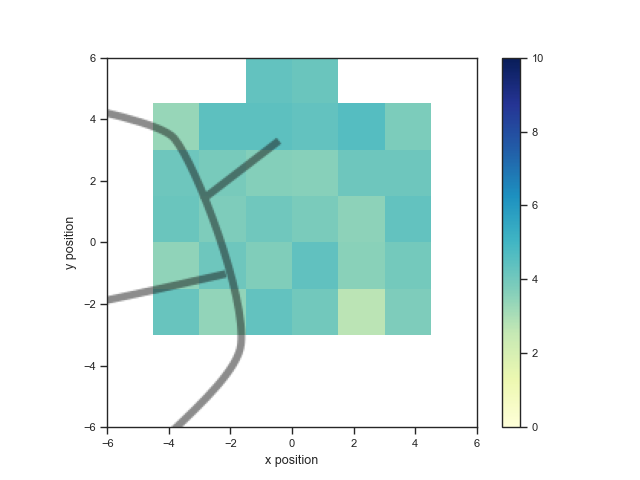

In [8]:
# Mean
im, pcm = plot_annotated_stim_drive_data(
    np.mean(power_20mW_input, axis=0), 
    'beignet', 'lm1', 0, cmap='YlGnBu'
)
im.set_clim(0,10)

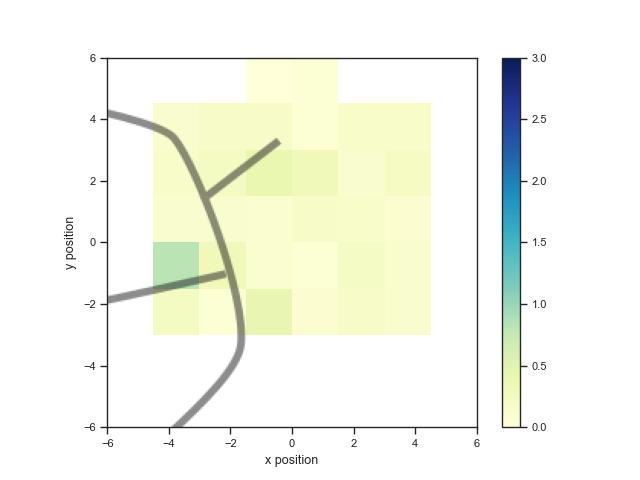

In [9]:
# Standard deviation
im, pcm = plot_annotated_stim_drive_data(
    np.std(power_20mW_input, axis=0), 
    'beignet', 'lm1', 0, cmap='YlGnBu'
)
im.set_clim(0,3)

In [10]:
# Stats
import statsmodels.api as sm

desc = sm.stats.DescrStatsW(np.mean(power_20mW_input, axis=0))
conf_int = desc.tconfint_mean(alpha=0.05)

print(f"95% confidence interval: ({conf_int[0]:.2f}, {conf_int[1]:.2f}) across space")

desc = sm.stats.DescrStatsW(np.mean(power_20mW_input, axis=1))
conf_int = desc.tconfint_mean(alpha=0.05)

print(f"95% confidence interval: ({conf_int[0]:.2f}, {conf_int[1]:.2f}) across repeated connections")

95% confidence interval: (3.80, 4.08) across space
95% confidence interval: (3.74, 4.14) across repeated connections


## Stim statistics

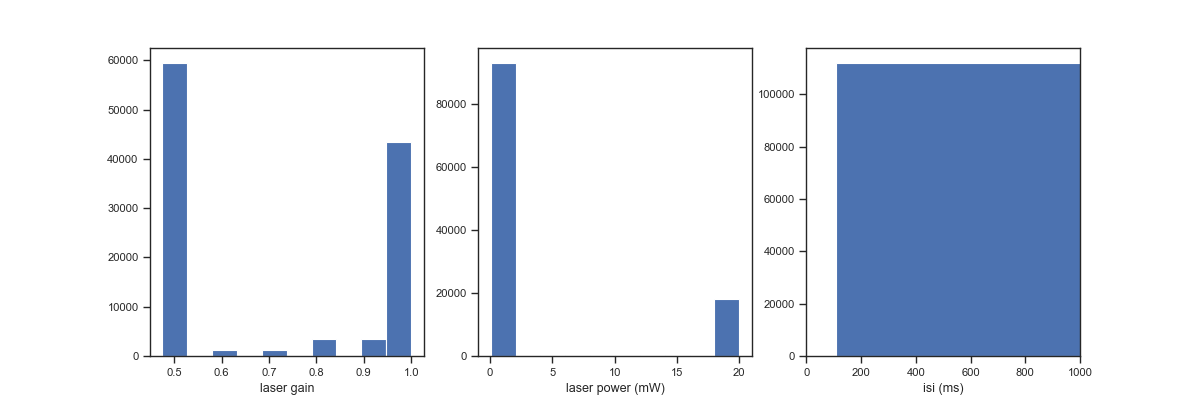

In [5]:
b_long_df = load_df(postproc_dir, 'beignet', 'rest_long', version)
trial_filter = filter_stim_trials(b_long_df, gain_range=[0.45, 0.55], min_isi=0.01)
b_long_df = b_long_df[trial_filter].reset_index()

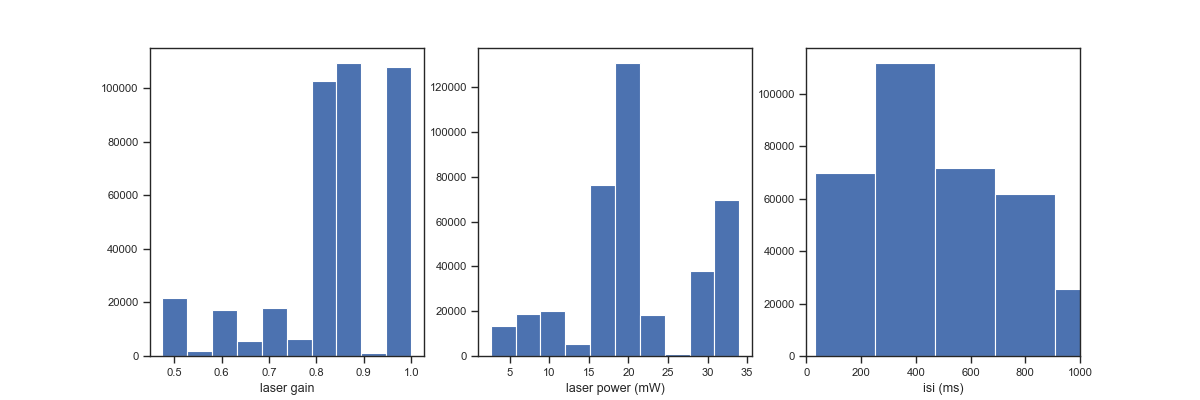

In [6]:
a_long_df = load_df(postproc_dir, 'affi', 'rest_long', version)
trial_filter = filter_stim_trials(a_long_df, min_isi=0.1)
a_long_df = a_long_df[trial_filter].reset_index()

Text(0.5, 0, 'gain')

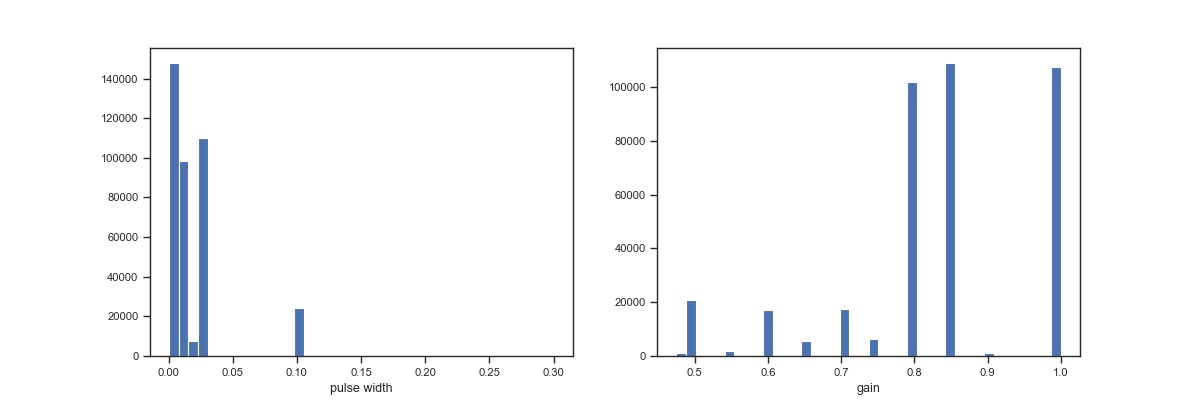

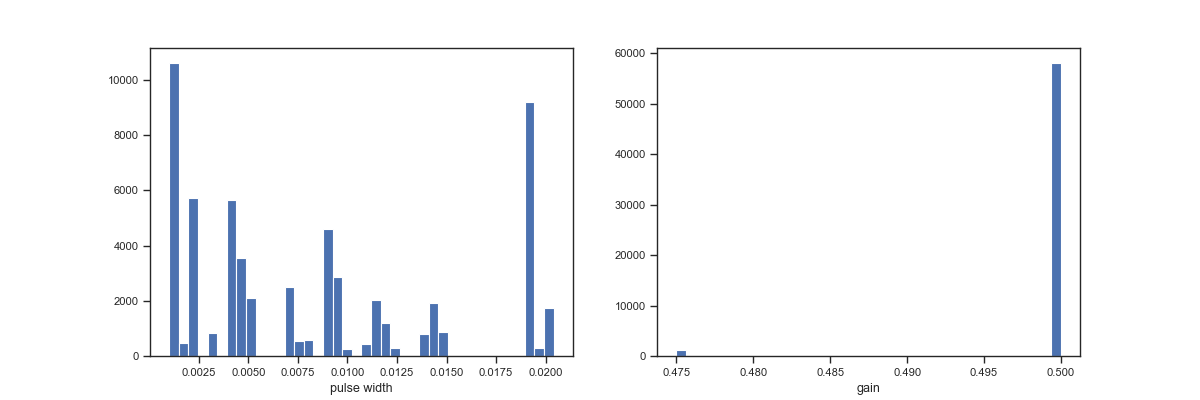

In [12]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(a_long_df['trial_width'], bins=40)
plt.xlabel('pulse width')
plt.subplot(1,2,2)
plt.hist(a_long_df['trial_gain'], bins=40)
plt.xlabel('gain')
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(b_long_df['trial_width'], bins=40)
plt.xlabel('pulse width')
plt.subplot(1,2,2)
plt.hist(b_long_df['trial_gain'], bins=40)
plt.xlabel('gain')


In [84]:
# Which sites are available
df_implant = None
for subject in ['beignet', 'affi']:
    print(subject)
    long_df = load_df(postproc_dir, subject, 'rest_long', version)    
    long_df['stimulation_site'] = long_df['stimulation_site'].astype(int)
    print('stim sites:', np.unique(long_df['stimulation_site']))

    # How many sites per day
    sites = []
    for date_idx, df in long_df.groupby('date'):
        sites.append(len(np.unique(df['stimulation_site'])))
    print(f'{np.mean(sites):.1f} ± {np.std(sites):.1f} (range {np.min(sites)} - {np.max(sites)}) sites per day')
    
    # How many days per implant after grouping
    days = []
    start_date = []
    end_date = []
    stim_sites = []
    for stim_site, df in long_df.groupby('stimulation_site'):
        df['implant'] = convert_days_to_implant(df['date'])
        for implant_idx, df in df.groupby('implant'):
                        
            # Only consider implants with 2+ days
            unique_days = np.unique(df['date'])
            if len(unique_days) >= 2:
                days.append(len(unique_days))
                start_date.append(unique_days[0])
                end_date.append(unique_days[-1])
                stim_sites.append(stim_site)
    print(f'{np.mean(days):.1f} ± {np.std(days):.1f} (range {np.min(days)} - {np.max(days)}) days per implant')
    
    # Compile the implants
    df_implant = pd.concat((df_implant, pd.DataFrame({'subject': subject, 'stim_site': stim_sites, 'start_date': start_date, 'end_date': end_date})))

beignet
stim sites: [ 1  4  7 11 15 24 28 31 32]
4.3 ± 2.6 (range 1 - 9) sites per day
13.3 ± 6.8 (range 2 - 26) days per implant
affi
stim sites: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32]
2.8 ± 2.2 (range 1 - 23) sites per day
9.6 ± 8.4 (range 2 - 40) days per implant


In [85]:
tsv = '''
Implant Date	Date Modified	Explant date	Animal
220104		220109	Beignet
220208		220223	Beignet
220315		220401	Beignet
220405		220412	Beignet
220601		220616	Beignet
220620		220630	Beignet
220907		220915	Beignet
220926	220929	221005	Beignet
221010		221014	Beignet
221020		221027	Beignet
221212		221226	Affi
221227		221228	Affi
230116		230209	Affi
230227		230313	Affi
230320	230329	230412	Affi
230516		230531	Affi
230724		230803	Affi
230807		230824	Affi
230906		230922	Affi
231002		231013	Affi
231016		231026	Affi
231106		231122	Affi
231128		231215	Affi
231226		240104	Affi
240108		240125	Affi
240130		240213	Affi
240304		240316	Affi
240320		240410	Affi
240411		240503	Affi
240515		240522	Affi
240617	240618	240621	Affi
240731		240802	Affi
'''
from io import StringIO
df = pd.read_csv(StringIO(tsv), delimiter='\t', parse_dates=['Implant Date','Date Modified','Explant date'],
                date_format='%y%m%d')
df['duration'] = df['Explant date'] - df['Implant Date']
display(df)
df['subject'] = df['Animal'].str.lower()
for subject in ['beignet', 'affi']:
    print(subject)
    days = df.loc[df['subject']==subject, 'duration'].dt.days
    print(f'{np.mean(days):.1f} ± {np.std(days):.1f} (range {np.min(days)} - {np.max(days)}) days per implant')


,Implant Date,Date Modified,Explant date,Animal,duration
0,2022-01-04,NaT,2022-01-09,Beignet,5 days
1,2022-02-08,NaT,2022-02-23,Beignet,15 days
2,2022-03-15,NaT,2022-04-01,Beignet,17 days
3,2022-04-05,NaT,2022-04-12,Beignet,7 days
4,2022-06-01,NaT,2022-06-16,Beignet,15 days
5,2022-06-20,NaT,2022-06-30,Beignet,10 days
6,2022-09-07,NaT,2022-09-15,Beignet,8 days
7,2022-09-26,2022-09-29,2022-10-05,Beignet,9 days
8,2022-10-10,NaT,2022-10-14,Beignet,4 days
9,2022-10-20,NaT,2022-10-27,Beignet,7 days


beignet
9.7 ± 4.3 (range 4 - 17) days per implant
affi
13.5 ± 6.2 (range 1 - 24) days per implant


In [86]:
# Compare to implants i denfined from data
display(df_implant)

,subject,stim_site,start_date,end_date
0,beignet,1,2022-02-09,2022-02-22
1,beignet,1,2022-03-15,2022-04-15
2,beignet,1,2022-06-03,2022-06-24
3,beignet,4,2022-02-09,2022-02-22
4,beignet,4,2022-03-15,2022-04-14
...,...,...,...,...
50,affi,31,2023-04-03,2023-04-11
51,affi,31,2023-05-22,2023-05-30
52,affi,31,2024-01-08,2024-01-11
53,affi,31,2024-01-16,2024-01-25


In [89]:
# How many times did the data "implants" cross span multiple physical implants?
df
for subject in ['beignet', 'affi']:
    print(subject)
    spans = 0
    for idx, row in df_implant[df_implant['subject'] == subject].iterrows():
        implant_start = np.where(pd.Timestamp(row['start_date']) >= df['Implant Date'])[0][-1]
        if df.loc[implant_start, 'Explant date'] < pd.Timestamp(row['end_date']):
            spans += 1
            print(row['stim_site'], df['Implant Date'][implant_start].date(), row['start_date'], row['end_date'], df['Explant date'][implant_start].date(), '*', sep='\t')
        else:
            print(row['stim_site'], df['Implant Date'][implant_start].date(), row['start_date'], row['end_date'], df['Explant date'][implant_start].date(), sep='\t')
    print(spans, '/', len(df_implant[df_implant['subject'] == subject]))

beignet
1	2022-02-08	2022-02-09	2022-02-22	2022-02-23
1	2022-03-15	2022-03-15	2022-04-15	2022-04-01	*
1	2022-06-01	2022-06-03	2022-06-24	2022-06-16	*
4	2022-02-08	2022-02-09	2022-02-22	2022-02-23
4	2022-03-15	2022-03-15	2022-04-14	2022-04-01	*
4	2022-06-01	2022-06-08	2022-06-16	2022-06-16
4	2022-06-20	2022-06-23	2022-06-27	2022-06-30
7	2022-02-08	2022-02-09	2022-02-22	2022-02-23
7	2022-06-20	2022-06-20	2022-06-25	2022-06-30
11	2022-02-08	2022-02-09	2022-02-22	2022-02-23
11	2022-03-15	2022-03-15	2022-04-14	2022-04-01	*
11	2022-06-01	2022-06-08	2022-06-27	2022-06-16	*
15	2022-02-08	2022-02-09	2022-02-22	2022-02-23
15	2022-03-15	2022-04-01	2022-04-15	2022-04-01	*
24	2022-02-08	2022-02-09	2022-02-22	2022-02-23
28	2022-02-08	2022-02-09	2022-02-22	2022-02-23
28	2022-06-20	2022-06-29	2022-06-30	2022-06-30
31	2022-02-08	2022-02-09	2022-02-22	2022-02-23
31	2022-06-20	2022-06-29	2022-06-30	2022-06-30
32	2022-02-08	2022-02-09	2022-02-22	2022-02-23
6 / 20
affi
1	2024-03-20	2024-03-20	2024-03-31	20